# Week 5 Integration Assignment — Full EDA Pipeline

This notebook performs a complete exploratory data analysis pipeline on a newly generated orders dataset.

The workflow follows the sequence:

**Generate → Diagnose → Clean → Verify → Visualize → Summarize**

The dataset is intentionally generated with several data-quality problems. These problems will first be diagnosed without modification, then addressed individually with justified cleaning decisions.

## 1. Dataset Generation

The orders dataset is generated from the exact specification provided for the integration assignment.

No cleaning or modification is performed during this stage. The purpose is to establish the raw dataset exactly as provided before beginning diagnosis.

In [3]:
import numpy as np
import pandas as pd

In [4]:
rng = np.random.default_rng(seed=42)
n = 5000

orders = pd.DataFrame({
    "order_id": np.arange(1, n + 1),
    "order_date": pd.date_range("2024-01-01", periods=n, freq="h"),
    "customer_id": rng.integers(1000, 1200, size=n),
    "product_category": rng.choice(
        ["Electronics", "electronics", "Home Goods", "Apparel", "Books"], size=n
    ),
    "quantity": rng.integers(1, 8, size=n),
    "unit_price": rng.normal(45, 20, size=n).round(2),
    "region": rng.choice(
        ["North", "South", "East", "West", None],
        size=n,
        p=[0.24, 0.24, 0.24, 0.24, 0.04]
    ),
})

# Introduce the mess, on purpose — do not skip this part
orders.loc[
    rng.choice(n, 150, replace=False),
    "customer_id"
] = None

orders.loc[
    rng.choice(n, 30, replace=False),
    "quantity"
] *= -1

orders.loc[
    rng.choice(n, 20, replace=False),
    "unit_price"
] = 4999.99

orders = pd.concat([
    orders,
    orders.sample(15, random_state=1)
])

### Initial Dataset Verification

Before performing any diagnosis or cleaning, the shape and first few records of the generated dataset are inspected to confirm that the required dataset was created successfully.

In [5]:
print("Dataset shape:", orders.shape)

Dataset shape: (5015, 7)


In [6]:
orders.head()

,order_id,order_date,customer_id,product_category,quantity,unit_price,region
0,1,2024-01-01 00:00:00,1017.0,Electronics,3,44.68,West
1,2,2024-01-01 01:00:00,1154.0,Electronics,2,20.69,East
2,3,2024-01-01 02:00:00,1130.0,Apparel,4,41.60,West
3,4,2024-01-01 03:00:00,1087.0,Apparel,5,26.26,South
4,5,2024-01-01 04:00:00,1086.0,Apparel,2,39.45,West


In [7]:
orders.columns

Index(['order_id', 'order_date', 'customer_id', 'product_category', 'quantity',
       'unit_price', 'region'],
      dtype='str')

### Initial Observation

The generated dataset contains 5,015 rows and 7 columns. The additional 15 rows result from the intentionally introduced duplicate records.

At this stage, no values have been cleaned or modified. The dataset is preserved in its raw generated form so that all data-quality problems can be identified during the diagnosis stage.

In [8]:
assert orders.shape == (5015, 7)

## 2. Diagnosis of the Raw Dataset

Before making any cleaning decisions, the raw dataset is inspected using structural, statistical, missing-value, and categorical diagnostics.

No values are modified during this section. The purpose is to identify every data-quality issue present in the dataset and record the evidence before deciding how each issue should be handled.

### 2.1 Initial Record Inspection

The first few records are inspected to understand the structure and types of information represented by each column.

In [9]:
orders.head()

,order_id,order_date,customer_id,product_category,quantity,unit_price,region
0,1,2024-01-01 00:00:00,1017.0,Electronics,3,44.68,West
1,2,2024-01-01 01:00:00,1154.0,Electronics,2,20.69,East
2,3,2024-01-01 02:00:00,1130.0,Apparel,4,41.60,West
3,4,2024-01-01 03:00:00,1087.0,Apparel,5,26.26,South
4,5,2024-01-01 04:00:00,1086.0,Apparel,2,39.45,West


### 2.2 Dataset Structure

The `.info()` output is used to inspect the number of records, column data types, non-null counts, and approximate memory usage.

The non-null counts are particularly important because they can reveal missing values before any cleaning is performed.

In [10]:
orders.info()

<class 'pandas.DataFrame'>
Index: 5015 entries, 0 to 3823
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          5015 non-null   int64         
 1   order_date        5015 non-null   datetime64[us]
 2   customer_id       4865 non-null   float64       
 3   product_category  5015 non-null   str           
 4   quantity          5015 non-null   int64         
 5   unit_price        5015 non-null   float64       
 6   region            4817 non-null   str           
dtypes: datetime64[us](1), float64(2), int64(2), str(2)
memory usage: 313.4 KB


### 2.3 Numerical Summary

Descriptive statistics are used to examine the numerical columns and identify unusual ranges or values that may require further investigation.

In [11]:
orders.describe()

,order_id,order_date,customer_id,quantity,unit_price
count,5015.000000,5015,4865.000000,5015.000000,5015.000000
mean,2500.953938,2024-04-14 03:57:14.177467,1099.294347,3.937188,65.215825
min,1.000000,2024-01-01 00:00:00,1000.000000,-7.000000,-25.580000
25%,1250.500000,2024-02-22 01:30:00,1049.000000,2.000000,31.325000
50%,2502.000000,2024-04-14 05:00:00,1098.000000,4.000000,44.290000
75%,3751.500000,2024-06-05 06:30:00,1150.000000,6.000000,57.985000
max,5000.000000,2024-07-27 07:00:00,1199.000000,7.000000,4999.990000
std,1443.030494,NaN,57.795512,2.077920,320.661972


### 2.4 Missing-Value Diagnosis

The number of missing values is calculated for every column. This provides direct evidence for identifying columns that require a missing-value handling decision.

In [12]:
orders.isna().sum()

order_id              0
order_date            0
customer_id         150
product_category      0
quantity              0
unit_price            0
region              198
dtype: int64

### Missing-Value Percentage

The percentage of missing values is calculated to understand the relative scale of missingness in each column rather than looking only at raw counts.

In [13]:
missing_summary = pd.DataFrame({
    "missing_count": orders.isna().sum(),
    "missing_percentage": orders.isna().mean() * 100
})

missing_summary

,missing_count,missing_percentage
order_id,0,0.000000
order_date,0,0.000000
customer_id,150,2.991027
product_category,0,0.000000
quantity,0,0.000000
unit_price,0,0.000000
region,198,3.948156


### 2.5 Categorical Value Inspection

The frequency distribution of categorical columns is inspected to identify unexpected categories, inconsistent capitalization, or other categorical inconsistencies.

In [14]:
orders["product_category"].value_counts(dropna=False)

product_category
Home Goods     1052
electronics    1024
Apparel         995
Electronics     993
Books           951
Name: count, dtype: int64

In [15]:
orders["region"].value_counts(dropna=False)

region
West     1240
East     1201
North    1201
South    1175
NaN       198
Name: count, dtype: int64

### 2.6 Quantity Validation

The quantity column is inspected for unusual values. A sales order quantity is expected to represent the number of units associated with an order, so negative quantities require investigation rather than being treated automatically as missing values.

In [16]:
orders["quantity"].value_counts().sort_index()

quantity
-7      2
-6      4
-5      6
-4      4
-3      1
-2      6
-1      7
 1    731
 2    687
 3    742
 4    699
 5    716
 6    726
 7    684
Name: count, dtype: int64

In [17]:
negative_quantity_count = (orders["quantity"] < 0).sum()

print("Negative quantity records:", negative_quantity_count)

Negative quantity records: 30


### 2.7 Unit Price Validation

The unit price distribution is inspected for unusually large values that may indicate data-entry errors or outliers.

In [18]:
orders["unit_price"].describe()

count    5015.000000
mean       65.215825
std       320.661972
min       -25.580000
25%        31.325000
50%        44.290000
75%        57.985000
max      4999.990000
Name: unit_price, dtype: float64

In [19]:
orders["unit_price"].nlargest(25)

229     4999.99
598     4999.99
699     4999.99
914     4999.99
979     4999.99
1101    4999.99
1497    4999.99
1951    4999.99
2134    4999.99
2150    4999.99
2440    4999.99
2452    4999.99
2701    4999.99
2936    4999.99
3391    4999.99
3485    4999.99
3594    4999.99
4100    4999.99
4160    4999.99
4362    4999.99
2701    4999.99
4274     128.02
776      125.52
1732     113.72
1934     109.67
Name: unit_price, dtype: float64

In [20]:
high_price_count = (orders["unit_price"] > 1000).sum()

print("Unit prices above 1000:", high_price_count)

Unit prices above 1000: 21


### 2.8 Duplicate Record Diagnosis

Duplicate records are checked separately because duplicate rows can distort counts, totals, averages, and other downstream analysis even when every individual field contains a valid value.

In [21]:
duplicate_count = orders.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 15


In [22]:
orders[orders.duplicated(keep=False)].sort_values("order_id").head(20)

,order_id,order_date,customer_id,product_category,quantity,unit_price,region
792,793,2024-02-03 00:00:00,1144.0,electronics,3,65.51,South
792,793,2024-02-03 00:00:00,1144.0,electronics,3,65.51,South
932,933,2024-02-08 20:00:00,1051.0,electronics,2,22.26,West
932,933,2024-02-08 20:00:00,1051.0,electronics,2,22.26,West
1179,1180,2024-02-19 03:00:00,1004.0,Books,5,36.74,West
1179,1180,2024-02-19 03:00:00,1004.0,Books,5,36.74,West
1185,1186,2024-02-19 09:00:00,1061.0,Books,5,45.70,South
1185,1186,2024-02-19 09:00:00,1061.0,Books,5,45.70,South
1724,1725,2024-03-12 20:00:00,1106.0,electronics,3,33.71,North
1724,1725,2024-03-12 20:00:00,1106.0,electronics,3,33.71,North


In [23]:
duplicate_order_ids = orders["order_id"].duplicated().sum()

print("Duplicate order IDs:", duplicate_order_ids)

Duplicate order IDs: 15


In [24]:
print("Minimum order date:", orders["order_date"].min())
print("Maximum order date:", orders["order_date"].max())

Minimum order date: 2024-01-01 00:00:00
Maximum order date: 2024-07-27 07:00:00


In [25]:
orders["order_date"].dtype

dtype('<M8[us]')

### 2.9 Diagnosis Summary

The diagnostic checks above are consolidated into a summary of the data-quality problems discovered in the raw dataset.

The purpose of this table is to ensure that every identified issue is explicitly recorded before any cleaning is performed.

In [29]:
diagnosis_summary = pd.DataFrame({
    "issue": [
        "Missing customer_id",
        "Missing region",
        "Inconsistent product_category casing",
        "Negative quantity",
        "Extreme unit_price values",
        "Duplicate records"
    ],
    "evidence": [
        f"{orders['customer_id'].isna().sum()} missing values",
        f"{orders['region'].isna().sum()} missing values",
        "Both 'Electronics' and 'electronics' appear as separate categories",
        f"{(orders['quantity'] < 0).sum()} negative values",
        f"{(orders['unit_price'] > 1000).sum()} values above 1000",
        f"{orders.duplicated().sum()} duplicate rows"
    ]
})

pd.set_option("display.max_colwidth", None)

diagnosis_summary.style.set_properties(
    **{
        "white-space": "pre-wrap",
        "text-align": "left"
    }
)

,issue,evidence
0,Missing customer_id,150 missing values
1,Missing region,198 missing values
2,Inconsistent product_category casing,Both 'Electronics' and 'electronics' appear as separate categories
3,Negative quantity,30 negative values
4,Extreme unit_price values,21 values above 1000
5,Duplicate records,15 duplicate rows


### Data-Quality Problems Identified

The raw dataset contains the following data-quality issues:

1. **Missing customer IDs:** The `customer_id` column contains missing values. Because customer identification is useful for customer-level analysis, these records require a specific missing-value handling decision.

2. **Missing regions:** The `region` column contains missing values. This affects regional analysis and therefore requires an explicit decision about whether the missing records should be retained or removed.

3. **Inconsistent category capitalization:** The `product_category` column contains both `Electronics` and `electronics`. These values represent the same category but would be treated as separate groups during aggregation unless standardized.

4. **Negative quantities:** The `quantity` column contains negative values. These are not missing values and require a business-rule decision because a negative quantity does not represent a standard positive sales quantity.

5. **Extreme unit prices:** The `unit_price` column contains unusually large values compared with the normal price range. These values require investigation because they may represent data-entry errors or intentional high-value transactions.

6. **Duplicate records:** Duplicate rows are present in the dataset. These records can cause orders to be counted more than once and can therefore distort downstream analysis.

## 3. Cleaning Decisions

The cleaning strategy is determined separately for each identified data-quality problem.

The goal is not to remove as much data as possible, but to choose the least destructive correction that preserves useful information while preventing invalid or duplicate records from distorting the analysis.

Each decision below is based on the diagnostic evidence collected in the previous section.

### 3.1 Missing `customer_id`

**Decision: Drop records with missing `customer_id`.**

The `customer_id` column is an identifier rather than a numerical measurement, so replacing missing IDs with a mean, median, or other invented value would create false customer identities.

Because customer-level analysis depends on a valid customer identifier, records without a `customer_id` will be removed rather than imputed.

### 3.2 Missing `region`

**Decision: Replace missing regions with `"Unknown"`.**

The region is a categorical attribute, and there is no reliable information available to infer the correct region for a missing value.

Dropping these orders would unnecessarily remove otherwise usable transaction information. Instead, missing regions will be represented explicitly as `"Unknown"` so that the records remain available for analysis without falsely assigning them to an existing region.

### 3.3 Inconsistent `product_category` Casing

**Decision: Standardize category names to lowercase.**

The values `Electronics` and `electronics` represent the same product category but would be treated as separate groups during aggregation.

The category values will therefore be normalized to lowercase so that equivalent categories are represented consistently.

### 3.4 Negative `quantity`

**Decision: Preserve return information and normalize the quantity value.**

The negative quantities represent returns rather than missing or randomly invalid values. Deleting these records would remove meaningful business events from the dataset.

A new `is_return` indicator will therefore record whether the original quantity was negative. The `quantity` value will then be converted to its absolute value so that the quantity field consistently represents the number of units involved in the transaction.

This approach preserves the return information while making the quantity field easier to interpret numerically.

### 3.5 Extreme `unit_price`

**Decision: Remove records containing the identified extreme unit-price values.**

The diagnostic analysis identified a small group of unit prices that are far outside the normal range of the generated dataset. These values are treated as data-entry outliers rather than valid high-value transactions for this exercise.

Replacing these prices with the mean or median would introduce artificial values. Therefore, the affected records will be removed from the cleaned analytical dataset.

### 3.6 Duplicate Records

**Decision: Remove exact duplicate rows.**

The duplicate records contain the same values as existing records and therefore do not represent additional orders.

Keeping them would cause transactions to be counted more than once and could distort aggregate statistics and visualizations. Exact duplicate rows will therefore be removed.

### 3.7 Cleaning Decision Summary

In [28]:
cleaning_decisions = pd.DataFrame({
    "issue": [
        "Missing customer_id",
        "Missing region",
        "Inconsistent product_category casing",
        "Negative quantity",
        "Extreme unit_price",
        "Duplicate rows"
    ],
    "decision": [
        "Drop rows",
        "Fill with 'Unknown'",
        "Normalize to lowercase",
        "Create is_return and use absolute quantity",
        "Remove affected records",
        "Drop exact duplicates"
    ],
    "reason": [
        "Customer IDs are identifiers and cannot be reliably inferred.",
        "The correct region cannot be inferred, but the remaining order data is still useful.",
        "Electronics and electronics represent the same category.",
        "Negative quantities represent returns and should not be discarded.",
        "The values are identified as data-entry outliers and should not be replaced with fabricated prices.",
        "Exact duplicate records would cause transactions to be counted more than once."
    ]
})

pd.set_option("display.max_colwidth", None)

cleaning_decisions.style.set_properties(
    **{
        "white-space": "pre-wrap",
        "text-align": "left"
    }
)

,issue,decision,reason
0,Missing customer_id,Drop rows,Customer IDs are identifiers and cannot be reliably inferred.
1,Missing region,Fill with 'Unknown',"The correct region cannot be inferred, but the remaining order data is still useful."
2,Inconsistent product_category casing,Normalize to lowercase,Electronics and electronics represent the same category.
3,Negative quantity,Create is_return and use absolute quantity,Negative quantities represent returns and should not be discarded.
4,Extreme unit_price,Remove affected records,The values are identified as data-entry outliers and should not be replaced with fabricated prices.
5,Duplicate rows,Drop exact duplicates,Exact duplicate records would cause transactions to be counted more than once.


## 4. Cleaning Implementation

The cleaning decisions established in the previous section are now applied to a separate copy of the raw dataset.

The original `orders` DataFrame is preserved so that the cleaned dataset can be compared against the original data and the effect of each cleaning operation can be verified.

In [30]:
cleaned_orders = orders.copy()

print("Raw dataset shape:", orders.shape)
print("Working dataset shape:", cleaned_orders.shape)

Raw dataset shape: (5015, 7)
Working dataset shape: (5015, 7)


### 4.1 Handling Missing `customer_id`

Records without a `customer_id` are removed because the identifier cannot be reliably inferred. Keeping these records would prevent reliable customer-level analysis.

In [31]:
missing_customer_id = cleaned_orders["customer_id"].isna().sum()

print("Missing customer_id before cleaning:", missing_customer_id)

Missing customer_id before cleaning: 150


In [32]:
cleaned_orders = cleaned_orders.dropna(subset=["customer_id"]).copy()

print("Shape after removing missing customer_id:", cleaned_orders.shape)

Shape after removing missing customer_id: (4865, 7)


In [33]:
print(
    "Remaining missing customer_id:",
    cleaned_orders["customer_id"].isna().sum()
)

Remaining missing customer_id: 0


### 4.2 Handling Missing `region`

Missing regions are represented as `Unknown` rather than removing the records because the remaining order information is still useful and the correct region cannot be reliably inferred.

In [34]:
missing_region = cleaned_orders["region"].isna().sum()

print("Missing region before filling:", missing_region)

Missing region before filling: 193


In [35]:
cleaned_orders["region"] = cleaned_orders["region"].fillna("Unknown")

In [36]:
print(
    "Remaining missing region:",
    cleaned_orders["region"].isna().sum()
)

Remaining missing region: 0


In [37]:
cleaned_orders["region"].value_counts(dropna=False)

region
West       1210
East       1166
North      1163
South      1133
Unknown     193
Name: count, dtype: int64

### 4.3 Standardizing `product_category`

The category values are converted to lowercase so that `Electronics` and `electronics` are treated as the same category during grouping and visualization.

In [38]:
cleaned_orders["product_category"].value_counts()

product_category
Home Goods     1019
electronics     989
Apparel         967
Electronics     960
Books           930
Name: count, dtype: int64

In [39]:
cleaned_orders["product_category"] = (
    cleaned_orders["product_category"]
    .str.strip()
    .str.lower()
)

In [40]:
cleaned_orders["product_category"].value_counts()

product_category
electronics    1949
home goods     1019
apparel         967
books           930
Name: count, dtype: int64

### 4.4 Handling Negative `quantity`

Negative quantities represent returns rather than missing or meaningless records. A new `is_return` indicator is created before converting the quantity to its absolute value.

This preserves the information that the transaction originally represented a return while allowing `quantity` to consistently represent the number of units involved.

In [41]:
cleaned_orders["is_return"] = cleaned_orders["quantity"] < 0

In [42]:
cleaned_orders["is_return"].value_counts()

is_return
False    4836
True       29
Name: count, dtype: int64

In [43]:
cleaned_orders["quantity"] = cleaned_orders["quantity"].abs()

In [44]:
print(
    "Negative quantities remaining:",
    (cleaned_orders["quantity"] < 0).sum()
)

Negative quantities remaining: 0


In [45]:
print(
    "Records identified as returns:",
    cleaned_orders["is_return"].sum()
)

Records identified as returns: 29


### 4.5 Handling Extreme `unit_price` Values

The diagnostic stage identified unusually large unit prices that are treated as data-entry outliers for this exercise.

These records are removed rather than replacing the prices with a mean or median because doing so would introduce fabricated price values.

In [46]:
extreme_price_count = (cleaned_orders["unit_price"] > 1000).sum()

print("Extreme unit-price records before cleaning:", extreme_price_count)

Extreme unit-price records before cleaning: 20


In [47]:
cleaned_orders = cleaned_orders[
    cleaned_orders["unit_price"] <= 1000
].copy()

In [48]:
print(
    "Extreme unit-price records remaining:",
    (cleaned_orders["unit_price"] > 1000).sum()
)

Extreme unit-price records remaining: 0


### 4.6 Removing Duplicate Records

Exact duplicate rows are removed because they do not represent additional orders and would otherwise cause transactions to be counted more than once.

In [49]:
duplicate_count = cleaned_orders.duplicated().sum()

print("Duplicate rows before cleaning:", duplicate_count)

Duplicate rows before cleaning: 14


In [50]:
cleaned_orders = cleaned_orders.drop_duplicates().copy()

In [51]:
print(
    "Duplicate rows remaining:",
    cleaned_orders.duplicated().sum()
)

Duplicate rows remaining: 0


### 4.7 Cleaned Dataset Overview

After applying the issue-specific cleaning decisions, the cleaned dataset is inspected to verify its final structure and confirm that the targeted problems have been addressed.

In [52]:
cleaned_orders.info()

<class 'pandas.DataFrame'>
Index: 4831 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          4831 non-null   int64         
 1   order_date        4831 non-null   datetime64[us]
 2   customer_id       4831 non-null   float64       
 3   product_category  4831 non-null   str           
 4   quantity          4831 non-null   int64         
 5   unit_price        4831 non-null   float64       
 6   region            4831 non-null   str           
 7   is_return         4831 non-null   bool          
dtypes: bool(1), datetime64[us](1), float64(2), int64(2), str(2)
memory usage: 306.7 KB


In [53]:
cleaned_orders.head()

,order_id,order_date,customer_id,product_category,quantity,unit_price,region,is_return
0,1,2024-01-01 00:00:00,1017.0,electronics,3,44.68,West,False
1,2,2024-01-01 01:00:00,1154.0,electronics,2,20.69,East,False
2,3,2024-01-01 02:00:00,1130.0,apparel,4,41.60,West,False
3,4,2024-01-01 03:00:00,1087.0,apparel,5,26.26,South,False
4,5,2024-01-01 04:00:00,1086.0,apparel,2,39.45,West,False


In [54]:
cleaned_orders.shape

(4831, 8)

### 4.8 Cleaning Verification

The known data-quality problems identified during diagnosis are checked again after cleaning. Each verification corresponds directly to one of the issues documented in the diagnosis section.

In [55]:
print("Missing customer_id:")
print(cleaned_orders["customer_id"].isna().sum())

print("\nMissing region:")
print(cleaned_orders["region"].isna().sum())

print("\nProduct categories:")
print(cleaned_orders["product_category"].value_counts())

print("\nNegative quantities:")
print((cleaned_orders["quantity"] < 0).sum())

print("\nExtreme unit prices:")
print((cleaned_orders["unit_price"] > 1000).sum())

print("\nDuplicate rows:")
print(cleaned_orders.duplicated().sum())

Missing customer_id:
0

Missing region:
0

Product categories:
product_category
electronics    1937
home goods     1010
apparel         962
books           922
Name: count, dtype: int64

Negative quantities:
0

Extreme unit prices:
0

Duplicate rows:
0


In [56]:
print("Raw dataset shape:", orders.shape)
print("Cleaned dataset shape:", cleaned_orders.shape)

Raw dataset shape: (5015, 7)
Cleaned dataset shape: (4831, 8)


In [57]:
before_after = pd.DataFrame({
    "metric": [
        "Rows",
        "Missing customer_id",
        "Missing region",
        "Negative quantity",
        "Extreme unit_price",
        "Duplicate rows"
    ],
    "before": [
        len(orders),
        orders["customer_id"].isna().sum(),
        orders["region"].isna().sum(),
        (orders["quantity"] < 0).sum(),
        (orders["unit_price"] > 1000).sum(),
        orders.duplicated().sum()
    ],
    "after": [
        len(cleaned_orders),
        cleaned_orders["customer_id"].isna().sum(),
        cleaned_orders["region"].isna().sum(),
        (cleaned_orders["quantity"] < 0).sum(),
        (cleaned_orders["unit_price"] > 1000).sum(),
        cleaned_orders.duplicated().sum()
    ]
})

before_after

,metric,before,after
0,Rows,5015,4831
1,Missing customer_id,150,0
2,Missing region,198,0
3,Negative quantity,30,0
4,Extreme unit_price,21,0
5,Duplicate rows,15,0


### Cleaning Result

The cleaning process addressed each identified data-quality issue individually rather than applying a blanket operation.

Records without customer identifiers were removed because the identifier could not be reliably inferred. Missing regions were retained and represented as `Unknown` so that otherwise usable orders were not discarded. Product categories were standardized to lowercase, negative quantities were converted to absolute values while preserving return information through `is_return`, extreme unit-price records were removed, and exact duplicate rows were eliminated.

The verification results confirm that the targeted missing values, negative quantities, extreme prices, and duplicate records no longer remain in the cleaned analytical dataset.

## 5. Visualization

The cleaned dataset is now visualized to investigate three different analytical questions.

Each visualization is selected according to the type of question being asked:

- A histogram is used to examine the distribution of order values.
- A bar chart is used to compare aggregated values across product categories.
- A scatter plot is used to examine the relationship between two numerical variables.

Each chart is created using Matplotlib's Figure and Axes interface.

### 5.1 Distribution of Unit Prices

**Question:** How are unit prices distributed across the cleaned orders?

A histogram is appropriate because the question concerns the distribution of a single numerical variable.

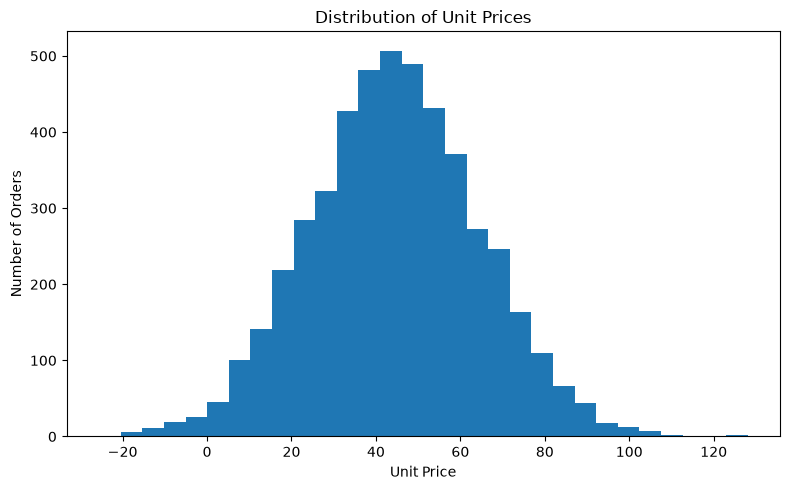

In [58]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    cleaned_orders["unit_price"],
    bins=30
)

ax.set_title("Distribution of Unit Prices")
ax.set_xlabel("Unit Price")
ax.set_ylabel("Number of Orders")

plt.tight_layout()
plt.show()

In [59]:
cleaned_orders["unit_price"].describe()

count    4831.000000
mean       44.531211
std        20.094093
min       -25.580000
25%        31.395000
50%        44.360000
75%        57.780000
max       128.020000
Name: unit_price, dtype: float64

### Finding

The unit-price histogram shows that most orders are concentrated within the lower-to-middle portion of the observed price range. The cleaned dataset no longer contains the extreme data-entry values identified during diagnosis.

The numerical summary above provides additional evidence for the observed range and central tendency of unit prices.

### 5.2 Quantity by Product Category

**Question:** Which product category has the highest total quantity ordered?

A bar chart is appropriate because it compares an aggregated numerical value across discrete product categories.

In [60]:
total_quantity_by_category = (
    cleaned_orders
    .groupby("product_category")["quantity"]
    .sum()
    .sort_values(ascending=False)
)

total_quantity_by_category

product_category
electronics    7818
home goods     4036
apparel        3747
books          3642
Name: quantity, dtype: int64

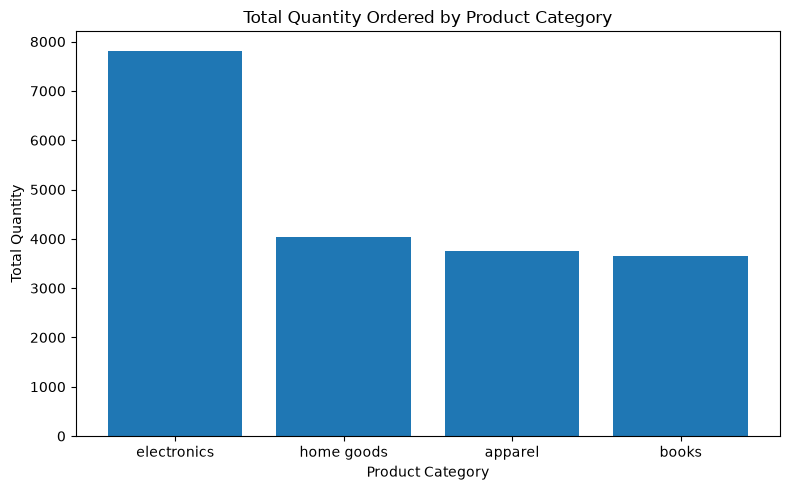

In [61]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    total_quantity_by_category.index,
    total_quantity_by_category.values
)

ax.set_title("Total Quantity Ordered by Product Category")
ax.set_xlabel("Product Category")
ax.set_ylabel("Total Quantity")

plt.tight_layout()
plt.show()

In [62]:
top_quantity_category = total_quantity_by_category.idxmax()
top_quantity = total_quantity_by_category.max()

print("Highest quantity category:", top_quantity_category)
print("Total quantity:", top_quantity)

Highest quantity category: electronics
Total quantity: 7818


### Finding

The category comparison shows that **electronics** has the highest total quantity ordered, with **7818 units** in the cleaned dataset.

The result is based on the grouped totals calculated above and is represented visually by the tallest bar in the chart.

### 5.3 Quantity vs Unit Price

**Question:** Is there an observable relationship between quantity ordered and unit price?

A scatter plot is appropriate because both variables are numerical and the purpose is to examine their relationship.

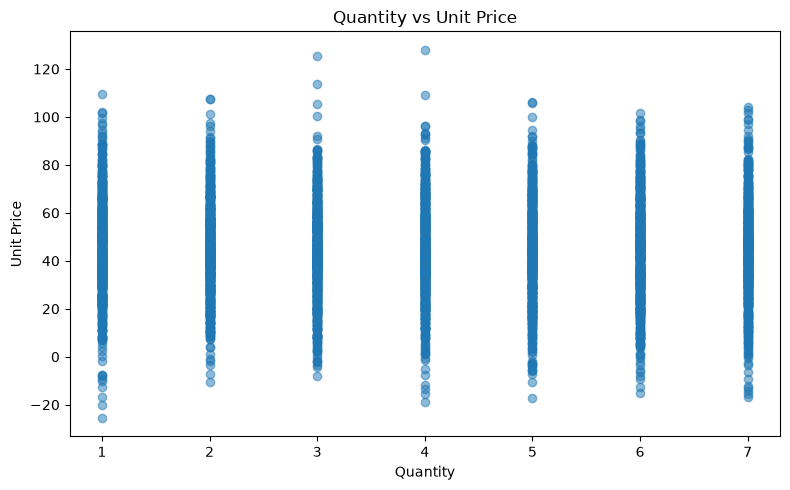

In [63]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    cleaned_orders["quantity"],
    cleaned_orders["unit_price"],
    alpha=0.5
)

ax.set_title("Quantity vs Unit Price")
ax.set_xlabel("Quantity")
ax.set_ylabel("Unit Price")

plt.tight_layout()
plt.show()

In [64]:
quantity_price_correlation = (
    cleaned_orders["quantity"]
    .corr(cleaned_orders["unit_price"])
)

print(
    "Correlation between quantity and unit price:",
    quantity_price_correlation
)

Correlation between quantity and unit price: -0.008686778341324395


### Finding

The scatter plot shows no clear linear relationship between quantity and unit price. The Pearson correlation coefficient is approximately **-0.009**, which is extremely close to zero and indicates a negligible linear association between the two variables.

Therefore, within this cleaned dataset, larger order quantities do not appear to consistently correspond to either higher or lower unit prices.

### 5.4 Visualization Quality Check

The three visualizations were selected according to the analytical question rather than using the same chart type for every variable.

- **Histogram:** used for the distribution of unit prices.
- **Bar chart:** used for comparing total quantities across product categories.
- **Scatter plot:** used for examining the relationship between quantity and unit price.

Each chart uses a Matplotlib `Figure` and `Axes` object and includes a descriptive title and labeled axes.

### 5.5 Orders by Region

**Question:** How many orders are associated with each region after handling missing regions?

A bar chart is appropriate because the goal is to compare order counts across discrete regions.

In [65]:
orders_by_region = (
    cleaned_orders["region"]
    .value_counts()
    .sort_values(ascending=False)
)

orders_by_region

region
West       1201
East       1161
North      1156
South      1121
Unknown     192
Name: count, dtype: int64

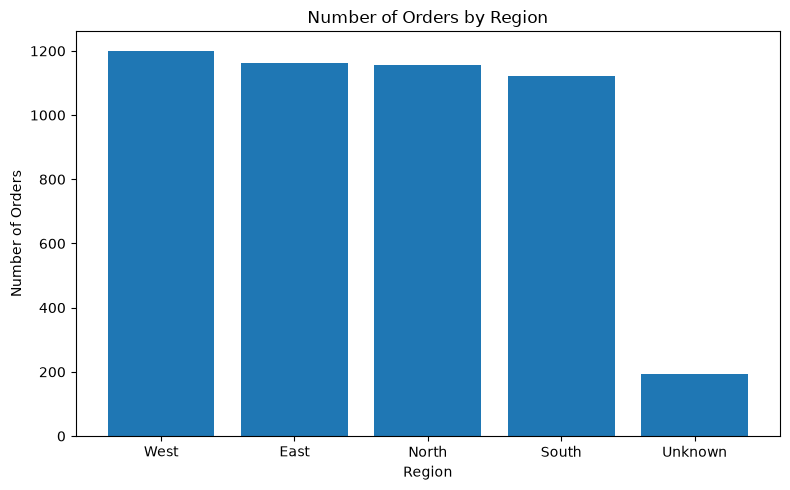

In [66]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    orders_by_region.index,
    orders_by_region.values
)

ax.set_title("Number of Orders by Region")
ax.set_xlabel("Region")
ax.set_ylabel("Number of Orders")

plt.tight_layout()
plt.show()

### Finding

The regional comparison shows how the cleaned orders are distributed across the available regions. The `Unknown` category represents orders for which the original dataset did not contain a region value.

Keeping these records as `Unknown` allows the remaining order information to contribute to the analysis without assigning them to an unsupported geographical region.